# PyTorch Replication: Deep Learning Stock Volatility with Google Domestic Trends

This notebook replicates the main experiment from `Deep Learning Stock Volatility with Google Domestic Trends` using PyTorch. It is wired to use the CSV layout from [philipperemy/stock-volatility-google-trends](https://github.com/philipperemy/stock-volatility-google-trends/tree/master): one `SP500.csv` file plus one Google Domestic Trend CSV per feature.

The notebook uses the local package in `src/replicate_volatility` for the core implementation so the same code can also be run from the command line.

In [3]:
from pathlib import Path
import json
import subprocess
import sys
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path("C:/Users/14806/Desktop/Emory/26 spring/datasci 347/final/svgt(1)/svgt")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

LOCAL_TRENDS_DIR = PROJECT_ROOT / "trends"
REPO_DIR = PROJECT_ROOT / "external" / "stock-volatility-google-trends"
TRENDS_DIR = LOCAL_TRENDS_DIR if LOCAL_TRENDS_DIR.exists() else REPO_DIR / "trends"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Trends directory:", TRENDS_DIR)

Project root: C:\Users\14806\Desktop\Emory\26 spring\datasci 347\final\svgt(1)\svgt
PyTorch: 2.11.0+cpu
Trends directory: C:\Users\14806\Desktop\Emory\26 spring\datasci 347\final\svgt(1)\svgt\external\stock-volatility-google-trends\trends


## Get the CSVs

If the referenced GitHub repo is not already cloned under `external/`, run the next cell. The repository includes the CSVs needed by this notebook.

In [4]:
if not TRENDS_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/philipperemy/stock-volatility-google-trends.git", str(REPO_DIR)],
        check=True,
    )
else:
    print("Repo already available:", REPO_DIR)

Repo already available: C:\Users\14806\Desktop\Emory\26 spring\datasci 347\final\svgt(1)\svgt\external\stock-volatility-google-trends


In [5]:
csv_files = sorted(TRENDS_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files")
print([p.name for p in csv_files[:10]], "...")

sp500_preview = pd.read_csv(TRENDS_DIR / "SP500.csv").head()
advert_preview = pd.read_csv(TRENDS_DIR / "advert.csv", encoding="utf-8-sig").head()
display(sp500_preview)
display(advert_preview)

Found 29 CSV files
['advert.csv', 'airtvl.csv', 'auto.csv', 'autoby.csv', 'autofi.csv', 'bizind.csv', 'bnkrpt.csv', 'comlnd.csv', 'comput.csv', 'constr.csv'] ...


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-10-05,1135.170044,1137.869995,1132.030029,1134.479980,1134.479980,1418400000
1,2004-10-06,1134.479980,1142.050049,1132.939941,1142.050049,1142.050049,1416700000
2,2004-10-07,1142.050049,1142.050049,1130.500000,1130.650024,1130.650024,1447500000
3,2004-10-08,1130.650024,1132.920044,1120.189941,1122.140015,1122.140015,1291600000
4,2004-10-11,1122.140015,1126.199951,1122.140015,1124.390015,1124.390015,943800000


,Date,Open,High,Low,Close,Volume
0,3-Oct-17,-,-,-,0.50,-
1,2-Oct-17,-,-,-,0.50,-
2,1-Oct-17,-,-,-,0.50,-
3,30-Sep-17,-,-,-,0.51,-
4,29-Sep-17,-,-,-,0.51,-


## Load and Prepare Data

The compatibility loader handles the repo's one-file-per-trend layout and maps `mtge.csv` to the paper abbreviation `mrtge`.

For the main replication, we use the paper's **70% train / 30% test** protocol. The public CSV starts in 2006 rather than 2004, so preserving the original absolute date boundaries would change the split to about 62% / 38%.

In [8]:
from replicate_volatility.data import (
    DOMESTIC_TRENDS,
    load_repo_data,
    make_sequences,
    mutual_information_by_feature,
    prepare_data,
)

raw_daily, feature_columns = load_repo_data(TRENDS_DIR, include_extra_trends=False)

# Main replication split: the paper says the whole data set is split into
# 70% training and 30% testing. The public GitHub CSV starts in 2006 rather
# than 2004, so using the original absolute date boundaries would no longer
# preserve the paper's 70/30 protocol.
prepared = prepare_data(
    raw_daily,
    feature_columns=feature_columns,
    delta_t=3,
    sequence_length=10,
    train_fraction=0.70,
)

print("Daily merged data:", raw_daily.shape, raw_daily.index.min().date(), "to", raw_daily.index.max().date())
total_rows = len(prepared.train) + len(prepared.test)
print("Training rows after 3-day aggregation:", prepared.train.shape)
print("Test rows after 3-day aggregation:", prepared.test.shape)
print("Training date range:", prepared.train.index.min().date(), "to", prepared.train.index.max().date())
print("Test date range:", prepared.test.index.min().date(), "to", prepared.test.index.max().date())
print(f"Split after aggregation: train={len(prepared.train) / total_rows:.1%}, test={len(prepared.test) / total_rows:.1%}")
print("Feature count:", len(prepared.feature_columns))
print(prepared.feature_columns)

Daily merged data: (2756, 25) 2006-10-23 to 2017-10-03
Training rows after 3-day aggregation: (641, 29)
Test rows after 3-day aggregation: (276, 29)
Training date range: 2006-10-25 to 2014-06-13
Test date range: 2014-06-18 to 2017-09-26
Split after aggregation: train=69.9%, test=30.1%
Feature count: 25
['return', 'volatility', 'advert', 'airtvl', 'autoby', 'autofi', 'bizind', 'bnkrpt', 'comput', 'crcard', 'durble', 'educat', 'invest', 'finpln', 'furntr', 'insur', 'jobs', 'luxury', 'mobile', 'mrtge', 'rlest', 'rental', 'shop', 'smallbiz', 'travel']


In [9]:
mi = mutual_information_by_feature(prepared)
mi.head(10).to_frame("mutual_information")

,mutual_information
volatility,0.475061
bnkrpt,0.286881
comput,0.235975
return,0.185976
invest,0.180701
rlest,0.149428
rental,0.142443
smallbiz,0.136245
finpln,0.135599
luxury,0.127287


In [10]:
SEQUENCE_LENGTH = 10
x_train, y_train, y_train_raw, train_dates = make_sequences(
    prepared.train, prepared.feature_columns, prepared.target_column, SEQUENCE_LENGTH
)
x_test, y_test, y_test_raw, test_dates = make_sequences(
    prepared.test, prepared.feature_columns, prepared.target_column, SEQUENCE_LENGTH
)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

x_train: (631, 10, 25) y_train: (631, 1)
x_test: (266, 10, 25) y_test: (266, 1)


## Some Visualizations

In [75]:
from sklearn.feature_selection import mutual_info_regression

In [92]:
from scipy.ndimage import gaussian_filter

In [104]:
# =========================
# grid (denser = smoother)
# =========================
dt_list = np.linspace(1, 6, 20)
k_list = np.linspace(5, 50, 25).astype(int)

mi_matrix = np.zeros((len(k_list), len(dt_list)))

# =========================
# main loop
# =========================
for i, k in enumerate(k_list):
    for j, dt in enumerate(dt_list):

        dt_int = int(round(dt))
        print(f"k={k}, Δt={dt_int}")

        try:
            # -------------------------
            # prepare data
            # -------------------------
            prepared_tmp = prepare_data(
                raw_daily,
                feature_columns=feature_columns,
                delta_t=dt_int,
                sequence_length=k,
                train_fraction=0.7
            )

            X = prepared_tmp.train[prepared_tmp.feature_columns]
            y = prepared_tmp.train[prepared_tmp.target_column]

            # -------------------------
            # normalize EACH FEATURE (important!)
            # -------------------------
            X_norm = X.copy()

            for col in X.columns:
                rolling_mean = X[col].rolling(window=k).mean()
                rolling_std = X[col].rolling(window=k).std().replace(0, np.nan)

                X_norm[col] = (X[col] - rolling_mean) / rolling_std

            # -------------------------
            # future volatility
            # -------------------------
            y_next = y.shift(-1)

            # -------------------------
            # clean data
            # -------------------------
            df = pd.concat([X_norm, y_next], axis=1)
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < 100:
                mi_matrix[i, j] = np.nan
                continue

            X_clean = df[prepared_tmp.feature_columns]
            y_clean = df.iloc[:, -1]

            # -------------------------
            # 🔥 KEY: MI per feature
            # -------------------------
            mi = mutual_info_regression(
                X_clean,
                y_clean,
                n_neighbors=10
            )

            # sum MI across features (paper assumption)
            mi_matrix[i, j] = np.sum(mi)

        except Exception as e:
            print(f"Error at k={k}, Δt={dt_int}: {e}")
            mi_matrix[i, j] = np.nan

k=5, Δt=1
k=5, Δt=1
k=5, Δt=2
k=5, Δt=2
k=5, Δt=2
k=5, Δt=2
k=5, Δt=3
k=5, Δt=3
k=5, Δt=3
k=5, Δt=3
k=5, Δt=4
k=5, Δt=4
k=5, Δt=4
k=5, Δt=4
k=5, Δt=5
k=5, Δt=5
k=5, Δt=5
k=5, Δt=5
k=5, Δt=6
k=5, Δt=6
k=6, Δt=1
k=6, Δt=1
k=6, Δt=2
k=6, Δt=2
k=6, Δt=2
k=6, Δt=2
k=6, Δt=3
k=6, Δt=3
k=6, Δt=3
k=6, Δt=3
k=6, Δt=4
k=6, Δt=4
k=6, Δt=4
k=6, Δt=4
k=6, Δt=5
k=6, Δt=5
k=6, Δt=5
k=6, Δt=5
k=6, Δt=6
k=6, Δt=6
k=8, Δt=1
k=8, Δt=1
k=8, Δt=2
k=8, Δt=2
k=8, Δt=2
k=8, Δt=2
k=8, Δt=3
k=8, Δt=3
k=8, Δt=3
k=8, Δt=3
k=8, Δt=4
k=8, Δt=4
k=8, Δt=4
k=8, Δt=4
k=8, Δt=5
k=8, Δt=5
k=8, Δt=5
k=8, Δt=5
k=8, Δt=6
k=8, Δt=6
k=10, Δt=1
k=10, Δt=1
k=10, Δt=2
k=10, Δt=2
k=10, Δt=2
k=10, Δt=2
k=10, Δt=3
k=10, Δt=3
k=10, Δt=3
k=10, Δt=3
k=10, Δt=4
k=10, Δt=4
k=10, Δt=4
k=10, Δt=4
k=10, Δt=5
k=10, Δt=5
k=10, Δt=5
k=10, Δt=5
k=10, Δt=6
k=10, Δt=6
k=12, Δt=1
k=12, Δt=1
k=12, Δt=2
k=12, Δt=2
k=12, Δt=2
k=12, Δt=2
k=12, Δt=3
k=12, Δt=3
k=12, Δt=3
k=12, Δt=3
k=12, Δt=4
k=12, Δt=4
k=12, Δt=4
k=12, Δt=4
k=12, Δt=5
k=12, Δt=5
k=12

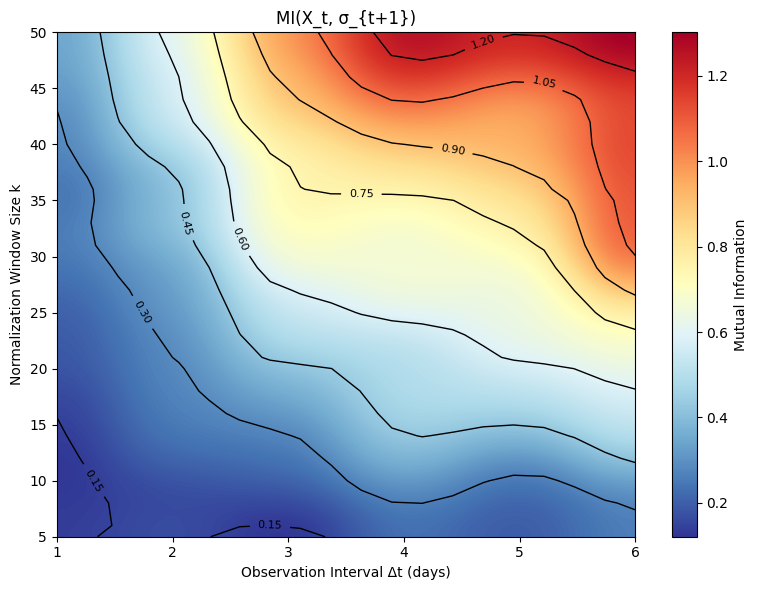


Best parameters:
k = 50
Δt = 6.0


In [105]:
mi_smooth = gaussian_filter(mi_matrix, sigma=1.2)


# =========================
# plot
# =========================
plt.figure(figsize=(8,6))

im = plt.imshow(
    mi_smooth,
    origin='lower',
    aspect='auto',
    cmap='RdYlBu_r',
    extent=[dt_list.min(), dt_list.max(), k_list.min(), k_list.max()],
    interpolation='bicubic'
)

plt.colorbar(im, label="Mutual Information")

# contour
X_grid, Y_grid = np.meshgrid(dt_list, k_list)

cs = plt.contour(
    X_grid,
    Y_grid,
    mi_smooth,
    colors='black',
    linewidths=1
)

plt.clabel(cs, inline=True, fontsize=8)

plt.xlabel("Observation Interval Δt (days)")
plt.ylabel("Normalization Window Size k")
plt.title("MI(X_t, σ_{t+1})")

plt.tight_layout()
plt.show()


# =========================
# best point
# =========================
idx = np.unravel_index(np.nanargmax(mi_smooth), mi_smooth.shape)

print("\nBest parameters:")
print("k =", k_list[idx[0]])
print("Δt =", dt_list[idx[1]])

## PyTorch LSTM0 and LSTMr

The public replication repo used a single `LSTM(32)` layer followed by `Dense(16, sigmoid)` and a linear output. This notebook implements the same architecture in PyTorch.

- `LSTM0`: all paper features: return, volatility, and Google Domestic Trends.
- `LSTMr`: reduced top-6 feature set from Figure 3: volatility, return, comput, crcard, invest, bnkrpt.

With the 70/30 split, local checks showed `LSTM0_EPOCHS = 60` and `LSTMR_EPOCHS = 600` give stable test MAPE values while avoiding full-feature overfitting.

In [69]:
from replicate_volatility.model import KerasReplicationLSTM
from replicate_volatility.metrics import mape_np, rmse_np, torch_mape
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LSTM0_EPOCHS = 60    # full-feature model overfits after this point in local 600-epoch checks
LSTMR_EPOCHS = 600   # reduced-feature model continues improving through 600 epochs
BATCH_SIZE = 32
LR = 1e-4            # matches the public Keras replication more closely
SEED = 7

REDUCED_FEATURES = ["volatility", "return", "comput", "crcard", "invest", "bnkrpt"]
missing = [c for c in REDUCED_FEATURES if c not in prepared.feature_columns]
if missing:
    raise ValueError(f"Reduced LSTM features missing from data: {missing}")

def inverse_target(y_z):
    return y_z * prepared.target_std + prepared.target_mean

def sequence_for_features(feature_cols):
    x_tr, y_tr, y_tr_raw, tr_dates = make_sequences(
        prepared.train, feature_cols, prepared.target_column, SEQUENCE_LENGTH
    )
    x_te, y_te, y_te_raw, te_dates = make_sequences(
        prepared.test, feature_cols, prepared.target_column, SEQUENCE_LENGTH
    )
    return x_tr, y_tr, y_tr_raw, x_te, y_te, y_te_raw, te_dates

def evaluate_lstm(model, x, y_raw):
    model.eval()
    with torch.no_grad():
        pred = inverse_target(model(torch.from_numpy(x).to(DEVICE))).cpu().numpy()
    return pred, {"rmse": rmse_np(y_raw, pred), "test_mape": mape_np(y_raw, pred)}

def train_lstm_model(name, feature_cols, epochs):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    x_tr, y_tr, y_tr_raw, x_te, y_te, y_te_raw, te_dates = sequence_for_features(feature_cols)
    model = KerasReplicationLSTM(input_size=x_tr.shape[-1], hidden_size=32, dense_size=16).to(DEVICE)

    loader = DataLoader(
        TensorDataset(torch.from_numpy(x_tr), torch.from_numpy(y_tr), torch.from_numpy(y_tr_raw)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, _, yraw in loader:
            xb = xb.to(DEVICE)
            yraw = yraw.to(DEVICE)
            pred_raw = inverse_target(model(xb))
            loss = torch_mape(yraw, pred_raw)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()) * 100.0)
        train_mape = float(np.mean(train_losses))
        history.append({"epoch": epoch, "train_mape": train_mape})
        if epoch == 1 or epoch % 20 == 0 or epoch == epochs:
            print(f"{name} epoch={epoch:04d} train_mape={train_mape:.2f}%")

    pred, metrics = evaluate_lstm(model, x_te, y_te_raw)
    return {
        "name": name,
        "model": model,
        "features": feature_cols,
        "history": history,
        "pred": pred,
        "metrics": metrics,
        "x_train": x_tr,
        "y_train_z": y_tr,
        "y_train_raw": y_tr_raw,
        "x_test": x_te,
        "y_test_z": y_te,
        "y_test_raw": y_te_raw,
        "test_dates": te_dates,
    }

print("device:", DEVICE)
print("LSTM0 feature count:", len(prepared.feature_columns))
print("LSTMr features:", REDUCED_FEATURES)

device: cpu
LSTM0 feature count: 25
LSTMr features: ['volatility', 'return', 'comput', 'crcard', 'invest', 'bnkrpt']


In [70]:
lstm0 = train_lstm_model("LSTM0", prepared.feature_columns, epochs=LSTM0_EPOCHS)
lstmr = train_lstm_model("LSTMr", REDUCED_FEATURES, epochs=LSTMR_EPOCHS)

pd.DataFrame({
    "LSTM0": lstm0["metrics"],
    "LSTMr": lstmr["metrics"],
}).T

LSTM0 epoch=0001 train_mape=90.24%
LSTM0 epoch=0020 train_mape=35.62%
LSTM0 epoch=0040 train_mape=26.85%
LSTM0 epoch=0060 train_mape=24.80%
LSTMr epoch=0001 train_mape=72.92%
LSTMr epoch=0020 train_mape=31.97%
LSTMr epoch=0040 train_mape=28.57%
LSTMr epoch=0060 train_mape=27.43%
LSTMr epoch=0080 train_mape=26.69%
LSTMr epoch=0100 train_mape=25.85%
LSTMr epoch=0120 train_mape=25.40%
LSTMr epoch=0140 train_mape=24.85%
LSTMr epoch=0160 train_mape=24.55%
LSTMr epoch=0180 train_mape=24.34%
LSTMr epoch=0200 train_mape=24.06%
LSTMr epoch=0220 train_mape=24.07%
LSTMr epoch=0240 train_mape=23.90%
LSTMr epoch=0260 train_mape=23.75%
LSTMr epoch=0280 train_mape=23.69%
LSTMr epoch=0300 train_mape=23.48%
LSTMr epoch=0320 train_mape=23.43%
LSTMr epoch=0340 train_mape=23.21%
LSTMr epoch=0360 train_mape=23.12%
LSTMr epoch=0380 train_mape=22.94%
LSTMr epoch=0400 train_mape=22.85%
LSTMr epoch=0420 train_mape=22.67%
LSTMr epoch=0440 train_mape=22.49%
LSTMr epoch=0460 train_mape=22.40%
LSTMr epoch=0480 tra

,rmse,test_mape
LSTM0,0.005356,37.728969
LSTMr,0.004598,29.976670


In [71]:
# Keep these common arrays for benchmarks and plotting.
x_train = lstm0["x_train"]
y_train_raw = lstm0["y_train_raw"]
x_test = lstm0["x_test"]
y_test_raw = lstm0["y_test_raw"]
test_dates = lstm0["test_dates"]
lstm_pred = lstm0["pred"]
lstm_metrics = lstm0["metrics"]

lstm_metrics

{'rmse': 0.005355711131213082, 'test_mape': 37.728969453558356}

## Benchmarks Required for the Replication

This section evaluates exactly the model families:

- `LSTM0`
- `LSTMr`
- `GARCH(1,1)`
- Linear Ridge
- Linear Lasso

Important fix: GARCH must be fit on raw aggregated returns, not z-scored returns. Using z-scored returns makes its volatility scale explode and produces nonsense MAPE values.

In [72]:
from replicate_volatility.baselines import fit_garch_or_fallback, fit_linear_grid, predict_linear

# Ridge/Lasso use the same lagged full feature matrix as LSTM0.
# The wider alpha grid avoids the overfitting that produced the earlier 100%+ Ridge MAPE.
ridge = fit_linear_grid(x_train, y_train_raw, "ridge")
lasso = fit_linear_grid(x_train, y_train_raw, "lasso")

ridge_pred = predict_linear(ridge, x_test)
lasso_pred = predict_linear(lasso, x_test)

# GARCH is fit on raw aggregated returns, then recursively one-step forecast over the test period.
garch_pred = fit_garch_or_fallback(
    prepared.train["return_raw"].to_numpy(),
    prepared.train["target_raw"].to_numpy(),
    horizon=len(y_test_raw),
    future_returns=prepared.test["return_raw"].to_numpy(),
    sequence_length=SEQUENCE_LENGTH,
)

metrics = {
    "LSTM0": lstm0["metrics"],
    "LSTMr": lstmr["metrics"],
    "Ridge": {"rmse": rmse_np(y_test_raw, ridge_pred), "test_mape": mape_np(y_test_raw, ridge_pred)},
    "Lasso": {"rmse": rmse_np(y_test_raw, lasso_pred), "test_mape": mape_np(y_test_raw, lasso_pred)},
    "GARCH": {"rmse": rmse_np(y_test_raw, garch_pred), "test_mape": mape_np(y_test_raw, garch_pred)},
}

results = pd.DataFrame(metrics).T
results["paper_mape"] = pd.Series({"LSTM0": 24.2, "LSTMr": 27.2, "GARCH": 34.9})
results

,rmse,test_mape,paper_mape
LSTM0,0.005356,37.728969,24.2
LSTMr,0.004598,29.976670,27.2
Ridge,0.004557,32.326198,NaN
Lasso,0.004320,35.474954,NaN
GARCH,0.005538,34.133416,34.9


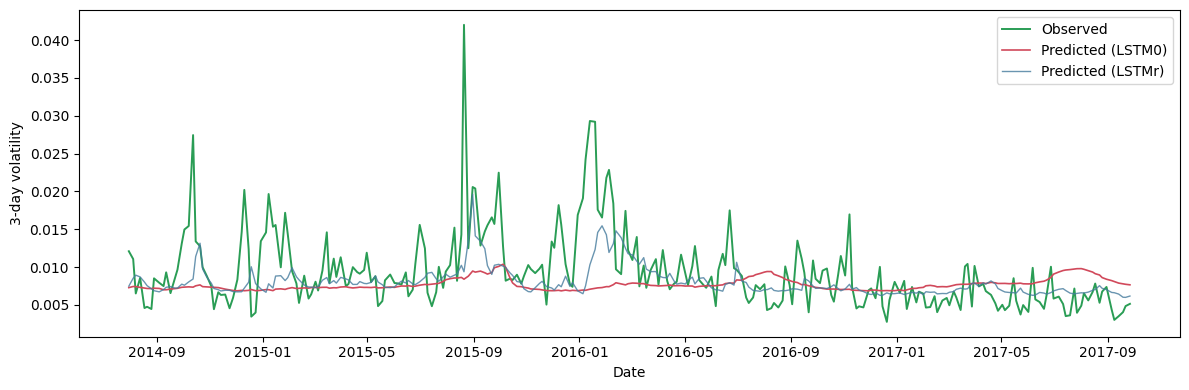

WindowsPath('C:/Users/14806/Desktop/Emory/26 spring/datasci 347/final/svgt(1)/svgt/outputs/notebook/notebook_lstm_predictions.png')

In [73]:
plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_test_raw.ravel(), label="Observed", color="#2a9d55", linewidth=1.4)
plt.plot(test_dates, lstm0["pred"].ravel(), label="Predicted (LSTM0)", color="#d1495b", linewidth=1.2)
plt.plot(test_dates, lstmr["pred"].ravel(), label="Predicted (LSTMr)", color="#457b9d", linewidth=1.0, alpha=0.8)
plt.ylabel("3-day volatility")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plot_path = OUTPUT_DIR / "notebook_lstm_predictions.png"
plt.savefig(plot_path, dpi=160)
plt.show()
plot_path

In [18]:
metrics_path = OUTPUT_DIR / "notebook_metrics.json"
checkpoint_path = OUTPUT_DIR / "notebook_lstm0_lstmr.pt"

metrics_path.write_text(json.dumps(metrics, indent=2))
torch.save({
    "lstm0_state": lstm0["model"].state_dict(),
    "lstmr_state": lstmr["model"].state_dict(),
    "lstm0_features": lstm0["features"],
    "lstmr_features": lstmr["features"],
}, checkpoint_path)

print("Wrote", metrics_path)
print("Wrote", checkpoint_path)

Wrote C:\Users\14806\Desktop\Emory\26 spring\datasci 347\final\svgt(1)\svgt\outputs\notebook\notebook_metrics.json
Wrote C:\Users\14806\Desktop\Emory\26 spring\datasci 347\final\svgt(1)\svgt\outputs\notebook\notebook_lstm0_lstmr.pt


## Extension

Compare feature selection methods for improving LSTM-based volatility prediction. We use elastic net and random forest and xgboost.

Elastic Net

In [22]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import numpy as np

x_train_ela = prepared.train[prepared.feature_columns]
y_train_ela = prepared.train[prepared.target_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_train_ela)

enet = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
enet.fit(X_scaled, y_train_ela)

selected_enet = x_train_ela.columns[np.abs(enet.coef_) > 1e-6]

print("Elastic Net selected:", list(selected_enet))

Elastic Net selected: ['return', 'volatility', 'advert', 'autoby', 'bizind', 'bnkrpt', 'crcard', 'educat', 'invest', 'finpln', 'furntr', 'insur', 'jobs', 'mobile', 'mrtge', 'rlest', 'rental', 'shop']


In [25]:
enet_features = list(selected_enet)
enet_result = train_lstm_model(
    name="LSTM_ENET",
    feature_cols=enet_features,
    epochs=600  # or same as baseline for fair comparison
)

LSTM_ENET epoch=0001 train_mape=69.86%
LSTM_ENET epoch=0020 train_mape=33.05%
LSTM_ENET epoch=0040 train_mape=27.18%
LSTM_ENET epoch=0060 train_mape=25.75%
LSTM_ENET epoch=0080 train_mape=24.75%
LSTM_ENET epoch=0100 train_mape=23.64%
LSTM_ENET epoch=0120 train_mape=23.05%
LSTM_ENET epoch=0140 train_mape=22.21%
LSTM_ENET epoch=0160 train_mape=21.85%
LSTM_ENET epoch=0180 train_mape=21.40%
LSTM_ENET epoch=0200 train_mape=20.98%
LSTM_ENET epoch=0220 train_mape=20.82%
LSTM_ENET epoch=0240 train_mape=20.51%
LSTM_ENET epoch=0260 train_mape=20.19%
LSTM_ENET epoch=0280 train_mape=19.93%
LSTM_ENET epoch=0300 train_mape=19.59%
LSTM_ENET epoch=0320 train_mape=19.41%
LSTM_ENET epoch=0340 train_mape=18.96%
LSTM_ENET epoch=0360 train_mape=18.88%
LSTM_ENET epoch=0380 train_mape=18.49%
LSTM_ENET epoch=0400 train_mape=18.25%
LSTM_ENET epoch=0420 train_mape=17.95%
LSTM_ENET epoch=0440 train_mape=17.57%
LSTM_ENET epoch=0460 train_mape=17.32%
LSTM_ENET epoch=0480 train_mape=17.22%
LSTM_ENET epoch=0500 trai

In [26]:
print(enet_result["metrics"])

{'rmse': 0.0053810284540999655, 'test_mape': 49.48706736957448}


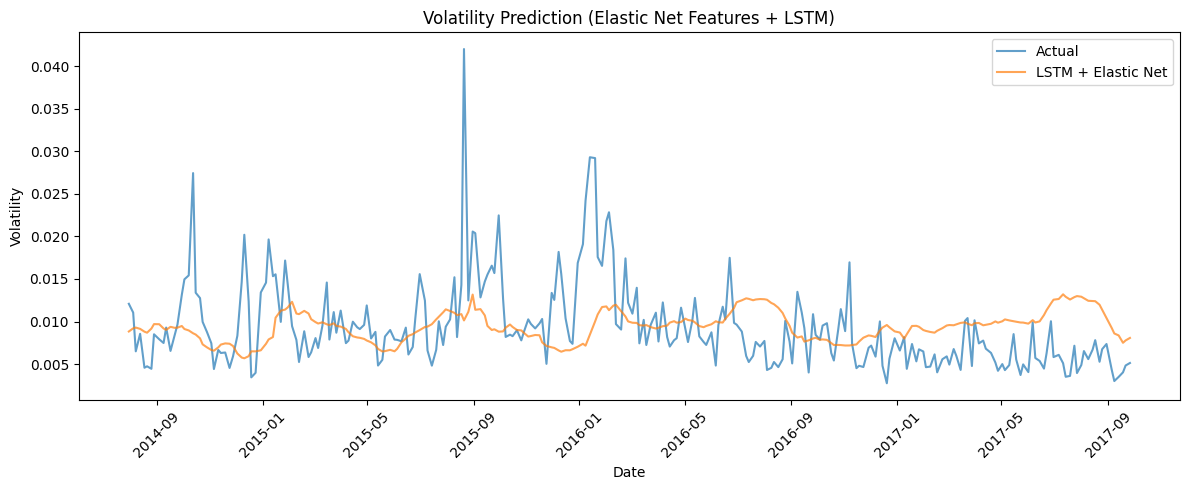

In [54]:
dates = enet_result["test_dates"]
pred_enet = enet_result["pred"]
y_true = enet_result["y_test_raw"]
plt.figure(figsize=(12,5))
plt.plot(dates, y_true, label="Actual", alpha=0.7)
plt.plot(dates, pred_enet, label="LSTM + Elastic Net", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Volatility Prediction (Elastic Net Features + LSTM)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Random Forest

In [33]:
results_rf = []

k_list = [5, 8, 10, 12, 15]

# train RF once
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X_train_rf = prepared.train[prepared.feature_columns]
y_train_rf = prepared.train[prepared.target_column]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)

importances = rf.feature_importances_

for k in k_list:
    print(f"\n===== Running k = {k} =====")
    
    # select top-k features
    indices = np.argsort(importances)[-k:]
    rf_features = list(X_train_rf.columns[indices])
    
    print("Selected features:", rf_features)
    
    # train LSTM
    rf_result = train_lstm_model(
        name=f"LSTM_RF_k{k}",
        feature_cols=rf_features,
        epochs=60
    )
    
    # store results
    results_rf.append({
        "model": f"LSTM_RF_k{k}",
        "k": k,
        "num_features": len(rf_features),
        "rmse": rf_result["metrics"]["rmse"],
        "test_mape": rf_result["metrics"]["test_mape"]
    })


===== Running k = 5 =====
Selected features: ['mrtge', 'rental', 'invest', 'return', 'volatility']
LSTM_RF_k5 epoch=0001 train_mape=97.16%
LSTM_RF_k5 epoch=0020 train_mape=32.83%
LSTM_RF_k5 epoch=0040 train_mape=29.15%
LSTM_RF_k5 epoch=0060 train_mape=27.61%

===== Running k = 8 =====
Selected features: ['bnkrpt', 'durble', 'educat', 'mrtge', 'rental', 'invest', 'return', 'volatility']
LSTM_RF_k8 epoch=0001 train_mape=36.90%
LSTM_RF_k8 epoch=0020 train_mape=32.41%
LSTM_RF_k8 epoch=0040 train_mape=27.22%
LSTM_RF_k8 epoch=0060 train_mape=25.90%

===== Running k = 10 =====
Selected features: ['finpln', 'jobs', 'bnkrpt', 'durble', 'educat', 'mrtge', 'rental', 'invest', 'return', 'volatility']
LSTM_RF_k10 epoch=0001 train_mape=39.23%
LSTM_RF_k10 epoch=0020 train_mape=32.23%
LSTM_RF_k10 epoch=0040 train_mape=27.71%
LSTM_RF_k10 epoch=0060 train_mape=25.91%

===== Running k = 12 =====
Selected features: ['furntr', 'airtvl', 'finpln', 'jobs', 'bnkrpt', 'durble', 'educat', 'mrtge', 'rental', 'i

In [34]:
df_rf = pd.DataFrame(results_rf)
df_rf.sort_values("test_mape")

,model,k,num_features,rmse,test_mape
1,LSTM_RF_k8,8,8,0.005101,32.136030
4,LSTM_RF_k15,15,15,0.005440,33.316460
3,LSTM_RF_k12,12,12,0.005336,33.345467
2,LSTM_RF_k10,10,10,0.005091,36.383918
0,LSTM_RF_k5,5,5,0.004954,50.296643


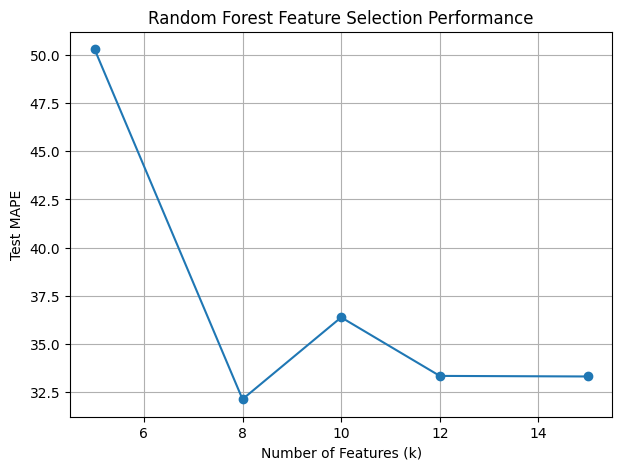

In [55]:
df_rf = pd.DataFrame(results_rf)

plt.figure(figsize=(7,5))
plt.plot(df_rf["k"], df_rf["test_mape"], marker='o')

plt.xlabel("Number of Features (k)")
plt.ylabel("Test MAPE")
plt.title("Random Forest Feature Selection Performance")

plt.grid(True)
plt.show()

LSTM_RF_k8


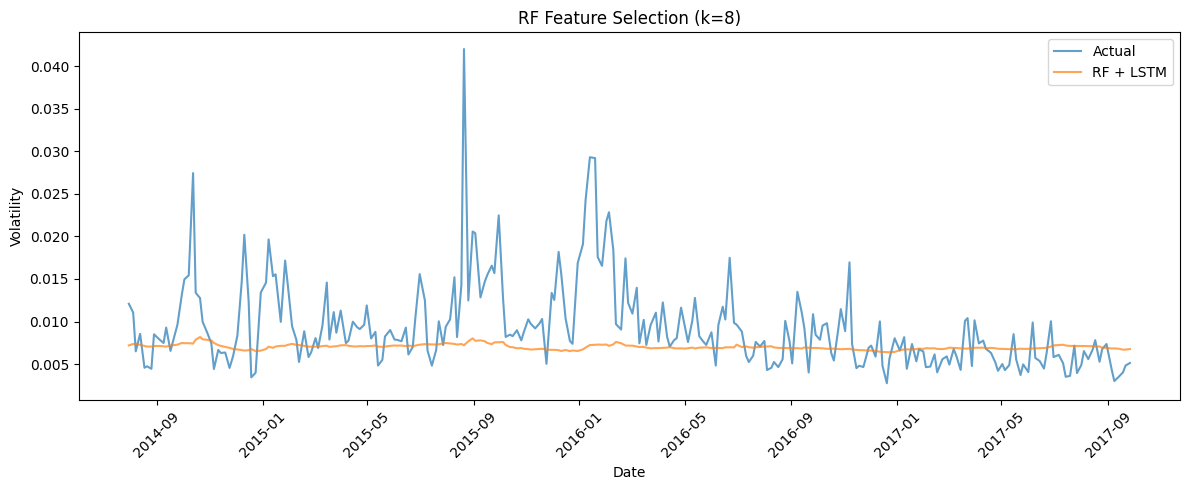

In [56]:
best_rf = min(results_rf, key=lambda x: x["test_mape"])
best_name = best_rf["model"]

print(best_name)
best_result = rf_result
dates = best_result["test_dates"]
y_true = best_result["y_test_raw"]
pred_rf = best_result["pred"]

plt.figure(figsize=(12,5))

plt.plot(dates, y_true, label="Actual", alpha=0.7)
plt.plot(dates, pred_rf, label="RF + LSTM", alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title(f"RF Feature Selection (k={best_rf['k']})")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

XGBoost

In [46]:
X_train_xg = prepared.train[prepared.feature_columns]

X_test_xg = prepared.test[prepared.feature_columns]
y_train_raw = prepared.train[prepared.target_column] * prepared.target_std + prepared.target_mean
y_test_raw  = prepared.test[prepared.target_column]  * prepared.target_std + prepared.target_mean

In [47]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_xg, y_train_raw)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [102]:
pred = xgb.predict(X_test_xg)

xgb_result = metrics = {
    "rmse": rmse_np(y_test_raw, pred),
    "test_mape": mape_np(y_test_raw, pred)
}

print(xgb_result)

{'rmse': 0.005850610546835967, 'test_mape': 53.41039198912855}


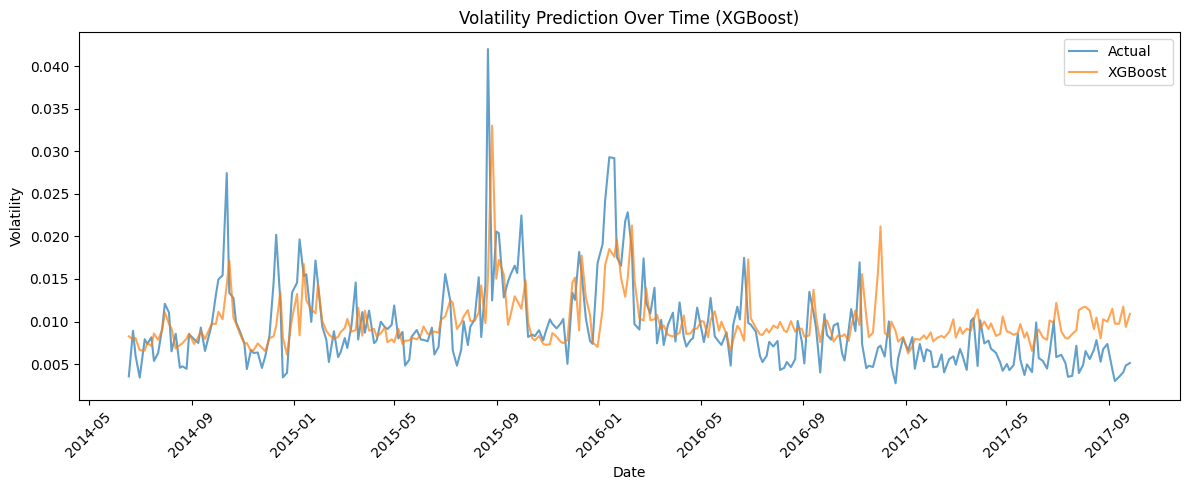

In [53]:
dates = prepared.test.index
plt.figure(figsize=(12,5))
plt.plot(dates, y_test_raw.values, label="Actual", alpha=0.7)
plt.plot(dates, pred, label="XGBoost", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Volatility Prediction Over Time (XGBoost)")
plt.legend()
plt.xticks(rotation=45)  # rotate for readability
plt.tight_layout()
plt.show()

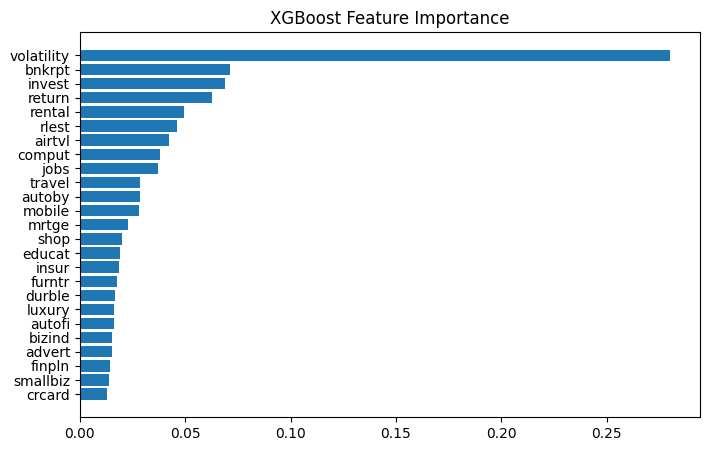

In [51]:
importances = xgb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train_xg.columns[indices])
plt.title("XGBoost Feature Importance")
plt.show()

## Transformer

In [96]:
import torch
import torch.nn as nn

class TransformerVolatility(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()

        self.input_proj = nn.Linear(input_size, d_model)

        # 🔥 ADD THIS
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=0.1
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)   # 🔥 CRITICAL LINE
        x = self.transformer(x)

        return self.fc(x[:, -1, :])

In [95]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, seq_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [97]:
def train_transformer_model(name, feature_cols, epochs):

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    x_tr, y_tr, y_tr_raw, x_te, y_te, y_te_raw, te_dates = sequence_for_features(feature_cols)

    model = TransformerVolatility(
        input_size=x_tr.shape[-1],
        d_model=32,
        nhead=2,
        num_layers=1
    ).to(DEVICE)

    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(x_tr),
            torch.from_numpy(y_tr),
            torch.from_numpy(y_tr_raw)
        ),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(epochs):
        model.train()

        for xb, _, yraw in loader:
            xb = xb.to(DEVICE)
            yraw = yraw.to(DEVICE)

            pred_raw = inverse_target(model(xb))
            loss = torch_mape(yraw, pred_raw)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    pred, metrics = evaluate_lstm(model, x_te, y_te_raw)

    return {
        "name": name,
        "model": model,
        "metrics": metrics,
        "pred": pred,
        "test_dates": te_dates
    }

In [98]:
transformer_result = train_transformer_model(
    name="Transformer",
    feature_cols=prepared.feature_columns,
    epochs=150
)

print(transformer_result["metrics"])

{'rmse': 0.0060449553092221, 'test_mape': 39.49333155503285}


In [103]:
results = pd.DataFrame([
    lstm0["metrics"],
    lstmr["metrics"],
    enet_result["metrics"],
    rf_result["metrics"],
    xgb_result,
    transformer_result["metrics"]
], index=["LSTM0", "LSTMR", "ElasticNet", "RF","XGB", "Transformer"])

print(results)

                 rmse  test_mape
LSTM0        0.005356  37.728969
LSTMR        0.004598  29.976670
ElasticNet   0.005381  49.487067
RF           0.005440  33.316460
XGB          0.005851  53.410392
Transformer  0.006045  39.493332
